In [1]:
import sys, os

sys.path.append(os.path.join(os.getcwd(),'..'))

from src.instance import Instance
from src.solution import Solution
from src.utils import show_solution, solution_compare_plot

In [5]:
import json

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

import pandas as pd
import numpy as np

In [3]:
runs_df = pd.read_csv('../results/runs.csv')
runs_df

,instance,profile,run,iteration,total_iterations,cost,k,optimal_cost,optimal_k,elapsed,routes
0,A-n45-k7,NN,0,0,7955,1944.989093,7,1146.0,7,0.017107,"[[0, 13, 7, 16, 35, 26, 38, 32, 8, 9, 21, 0], ..."
1,A-n45-k7,NN,0,1,7955,1902.544737,7,1146.0,7,0.033622,"[[0, 32, 29, 17, 44, 14, 0], [0, 21, 12, 26, 3..."
2,A-n45-k7,NN,0,2,7955,1822.959824,7,1146.0,7,0.049780,"[[0, 10, 11, 44, 37, 33, 0], [0, 32, 1, 17, 25..."
3,A-n45-k7,NN,0,5,7955,1783.534268,7,1146.0,7,0.097736,"[[0, 7, 20, 18, 5, 31, 24, 14, 0], [0, 37, 30,..."
4,A-n45-k7,NN,0,18,7955,1778.165891,7,1146.0,7,0.246899,"[[0, 6, 27, 19, 31, 36, 3, 0], [0, 32, 9, 41, ..."
...,...,...,...,...,...,...,...,...,...,...,...
8939,P-n50-k10,HAS-5,4,746,7143,730.458830,10,696.0,10,11.822824,"[[0, 8, 13, 19, 14, 35, 7, 0], [0, 4, 48, 47, ..."
8940,P-n50-k10,HAS-5,4,748,7143,730.458830,10,696.0,10,11.852352,"[[0, 31, 25, 18, 24, 16, 0], [0, 4, 48, 47, 21..."
8941,P-n50-k10,HAS-5,4,749,7143,730.458830,10,696.0,10,11.867810,"[[0, 17, 40, 12, 26, 0], [0, 4, 48, 47, 21, 0]..."
8942,P-n50-k10,HAS-5,4,750,7143,730.458830,10,696.0,10,11.886238,"[[0, 34, 46, 27, 29, 45, 0], [0, 4, 48, 47, 21..."


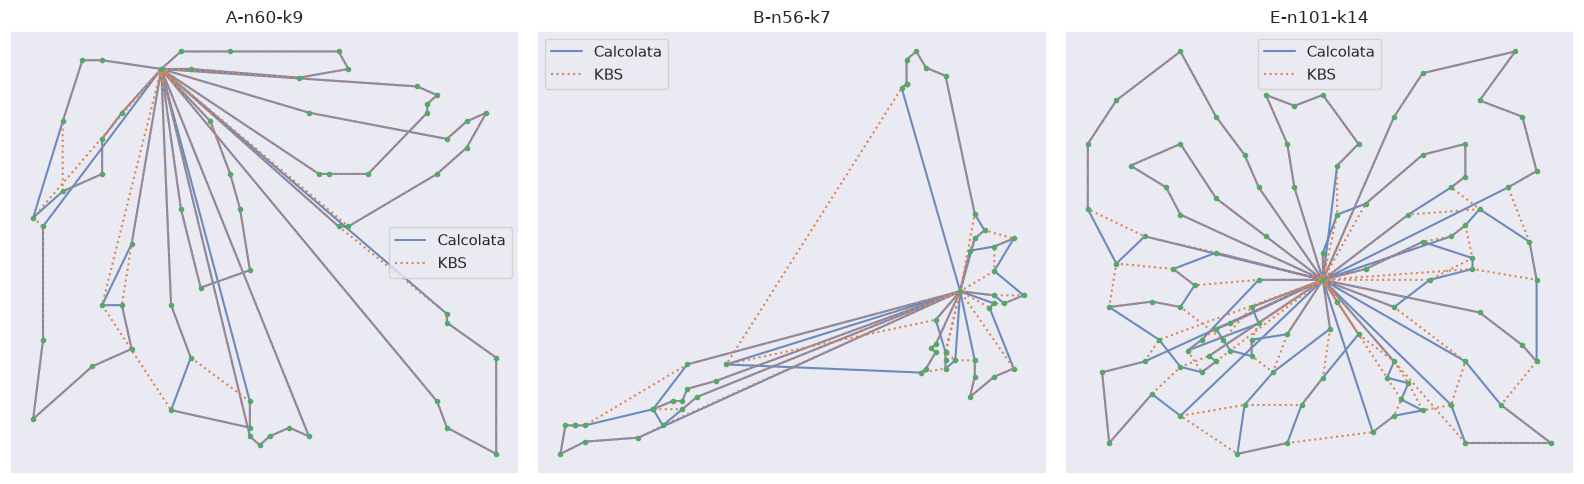

In [19]:

instances = [
	'A-n60-k9',
	'B-n56-k7',
	'E-n101-k14'
]
fig, axes = plt.subplots(1,3, figsize=(16,5))
fig.tight_layout()
for name, ax in zip(instances, axes ):
	
	idf = runs_df[runs_df['instance'] == name]
	sol = idf.sort_values('cost').iloc[0]
	cost, routes = sol['cost'], json.loads(sol['routes'])
	instance = Instance.load_vrp(f'../instances/{name}.vrp')
	best_sol = Solution.load_sol(f'../instances/sol/{name}.sol', instance, lenient=True)
	my_sol = Solution(routes, cost)
	solution_compare_plot(instance, best_sol, my_sol, ax)
	ax.set_xticks([])
	ax.set_yticks([])
	ax.legend()
	ax.set(title=name)

	#
fig.tight_layout()
plt.show()
	#display(idf2)